# 03. 추가 검증 — Batch 3

`02_modeling.ipynb` 에서 확정한 최종 모델(Linear · `dq_var`, `dq_lowv_mean`)을 **바꾸지 않고** Batch 3 에 그대로 적용해 성능을 확인한다.
Batch 3 결과를 보고 모델을 다시 고르면 추가 검증의 의미가 없어지기 때문이다.

**Batch 3 를 다룰 때 확인할 점**
- Cycle Life 분포가 배치별로 다르다 → 1절에서 확인
- 충전 커브 시작 시점이 배치별로 다르다 → `01_EDA.ipynb` Q3 에서 `Qdlin` 이 세 배치 모두 3.5V 에서 0Ah 로 시작하는 것을 확인했고, ΔQ 는 같은 셀의 두 사이클을 빼는 값이라 영향이 없다고 판단했다
- 이상치 제거 고려 → 5절에서 오차가 큰 셀을 확인

**Reporting** : 02 의 성능표에 Batch 3 행(Test, Gap)을 추가한다. Gap (Batch2-Batch3) 은 "Batch 3 MAPE − Batch 2 MAPE" → (+) 면 Batch 3 에서 더 나쁨

In [1]:
import sys, warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.train import (FEATURE_SETS, MODELS, ROBUST_SETS, LINEAR_MODELS, PLAN_SETS, TARGET_MAPE,
                       load_dataset, holdout_policies, compare_all, select_by_valid, covariate_shift,
                       report_table_b3, predict, mape)
from src.viz import set_style, BATCH_COLORS, MUTED, TEXT, GRID

set_style()
pd.set_option("display.precision", 2)
FIG_DIR = Path("../results/figures")
RESULTS_DIR = Path("../results")


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


def short(fs):
    return fs.split(" ")[0]

---
## 1. Batch 3 데이터

In [2]:
b1, b2, b3 = load_dataset(include_b3=True)
pd.DataFrame({
    "셀 수": [len(b1), len(b2), len(b3)],
    "newstructure 셀": [b1["newstructure"].sum(), b2["newstructure"].sum(), b3["newstructure"].sum()],
    "수명 최소": [b1["cycle_life"].min(), b2["cycle_life"].min(), b3["cycle_life"].min()],
    "수명 중앙값": [b1["cycle_life"].median(), b2["cycle_life"].median(), b3["cycle_life"].median()],
    "수명 최대": [b1["cycle_life"].max(), b2["cycle_life"].max(), b3["cycle_life"].max()],
}, index=["Batch 1 (학습)", "Batch 2 (Test)", "Batch 3 (추가 검증)"]).astype(int)

,셀 수,newstructure 셀,수명 최소,수명 중앙값,수명 최대
Batch 1 (학습),36,0,534,772,1074
Batch 2 (Test),39,9,392,472,1186
Batch 3 (추가 검증),44,44,541,1005,1935


In [3]:
print("Batch 1 수명 범위 밖 셀 :",
      f"짧음 {(b3['cycle_life'] < b1['cycle_life'].min()).sum()}개,",
      f"김 {(b3['cycle_life'] > b1['cycle_life'].max()).sum()}개 / {len(b3)}개")
print("\nBatch 2 · Batch 3 피처 분포 이동 (정답 사용 안 함)")
shift_cols = ["dq_var", "dq_lowv_mean", "qd_2", "fade_slope_91_100"]
pd.concat({"Batch 2": covariate_shift(b1, b2, shift_cols), "Batch 3": covariate_shift(b1, b3, shift_cols)}, axis=1).round(2)

Batch 1 수명 범위 밖 셀 : 짧음 0개, 김 16개 / 44개

Batch 2 · Batch 3 피처 분포 이동 (정답 사용 안 함)


Batch 2                          \
                  Batch 1 범위 밖 비율 (%) 평균 차이 (Batch 1 표준편차 단위)   
feature                                                         
dq_var                          43.59                    0.84   
dq_lowv_mean                    25.64                    0.89   
qd_2                            53.85                    1.88   
fade_slope_91_100               79.49                    0.65   

                              Batch 3                          
                  Batch 1 범위 밖 비율 (%) 평균 차이 (Batch 1 표준편차 단위)  
feature                                                        
dq_var                          47.73                   -1.73  
dq_lowv_mean                     6.82                   -1.15  
qd_2                            13.64                   -1.72  
fade_slope_91_100                4.55                   -0.37

**[확인]**
- Batch 3 는 44셀 모두 newstructure 이고, 수명이 541 ~ 1935 로 Batch 1(534 ~ 1074)보다 **긴 쪽**으로 벗어난다 (Batch 2 는 짧은 쪽)
- 최종 모델 피처 `dq_var` 는 Batch 3 에서 Batch 1 보다 낮은 쪽(수명이 긴 방향)으로 이동했다
- `qd_2` 는 Batch 2 에서 +1.88, Batch 3 에서 −1.72 로 **배치마다 반대 방향**으로 이동했다

---
## 2. 최종 모델 적용 — Batch 3 성능

In [4]:
valid_policies = holdout_policies(b1)
comparison, details = compare_all(b1, b2, valid_policies)

final = select_by_valid(comparison, LINEAR_MODELS, ROBUST_SETS)
final_r = details[(final["model"], final["feature_set"])]
final_cols = FEATURE_SETS[final["feature_set"]]
b3_pred = predict(final_r, b3, final_cols)

print(f"최종 모델 : {final['model']} · {final['feature_set']}  (02_modeling 과 동일, 다시 선택하지 않음)")
performance_b3 = report_table_b3(final_r, mape(b3["cycle_life"], b3_pred))
performance_b3.to_csv(RESULTS_DIR / "model_performance_batch3.csv")
performance_b3

최종 모델 : Linear · S2 + dq_lowv_mean  (02_modeling 과 동일, 다시 선택하지 않음)


,MAPE (%),계산,비고
구분,,,
Train (Batch 1 CV),8.79,,
Valid (Batch 1 Hold-out),10.48,,
Test (Batch 2),29.76,,
Gap (Train-Valid),1.70,Valid − Train,(+) : 과적합 의심
Gap (Valid-Test),19.28,Test − Valid,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),20.66,Test − Target(9.1),Target : 원논문 9.1%
Test (Batch 3),14.95,,
Gap (Batch2-Batch3),-14.81,Batch 3 − Batch 2,Test 성능 간 비교
Gap (Target-Test) · Batch 3,5.85,Batch 3 − Target(9.1),"Batch 3 기준, 원논문 성능 비교"


### 다른 모델과 비교 (참고)

최종 모델 선택에는 쓰지 않고, 배치가 바뀔 때 모델별로 성능이 얼마나 흔들리는지 보기 위한 비교다.

In [5]:
first = select_by_valid(comparison, list(MODELS), PLAN_SETS)
show = [(final["model"], final["feature_set"], f"최종 : {final['model']} · {short(final['feature_set'])}"),
        (first["model"], first["feature_set"], f"1차 : {first['model']} · {short(first['feature_set'])}"),
        ("ElasticNet", "ALL 후보 20개 (비교용)", "참고 : ElasticNet · ALL"),
        ("XGBoost", "S3 + qd_2, fade_slope_91_100", "트리 : XGBoost · S3")]

preds_b3 = {title: predict(details[(m, fs)], b3, FEATURE_SETS[fs]) for m, fs, title in show}
cmp = pd.DataFrame({
    title: {"Valid (Batch 1 Hold-out)": details[(m, fs)]["valid"],
            "Test (Batch 2)": details[(m, fs)]["test"],
            "Test (Batch 3)": mape(b3["cycle_life"], preds_b3[title])}
    for m, fs, title in show
}).T
cmp["Gap (Batch2-Batch3)"] = cmp["Test (Batch 3)"] - cmp["Test (Batch 2)"]
cmp.round(2)

,Valid (Batch 1 Hold-out),Test (Batch 2),Test (Batch 3),Gap (Batch2-Batch3)
최종 : Linear · S2,10.48,29.76,14.95,-14.81
1차 : Linear · S3,7.93,43.46,10.80,-32.66
참고 : ElasticNet · ALL,7.81,27.27,10.37,-16.90
트리 : XGBoost · S3,9.90,41.20,20.19,-21.01


---
## 3. 예측 vs 실제

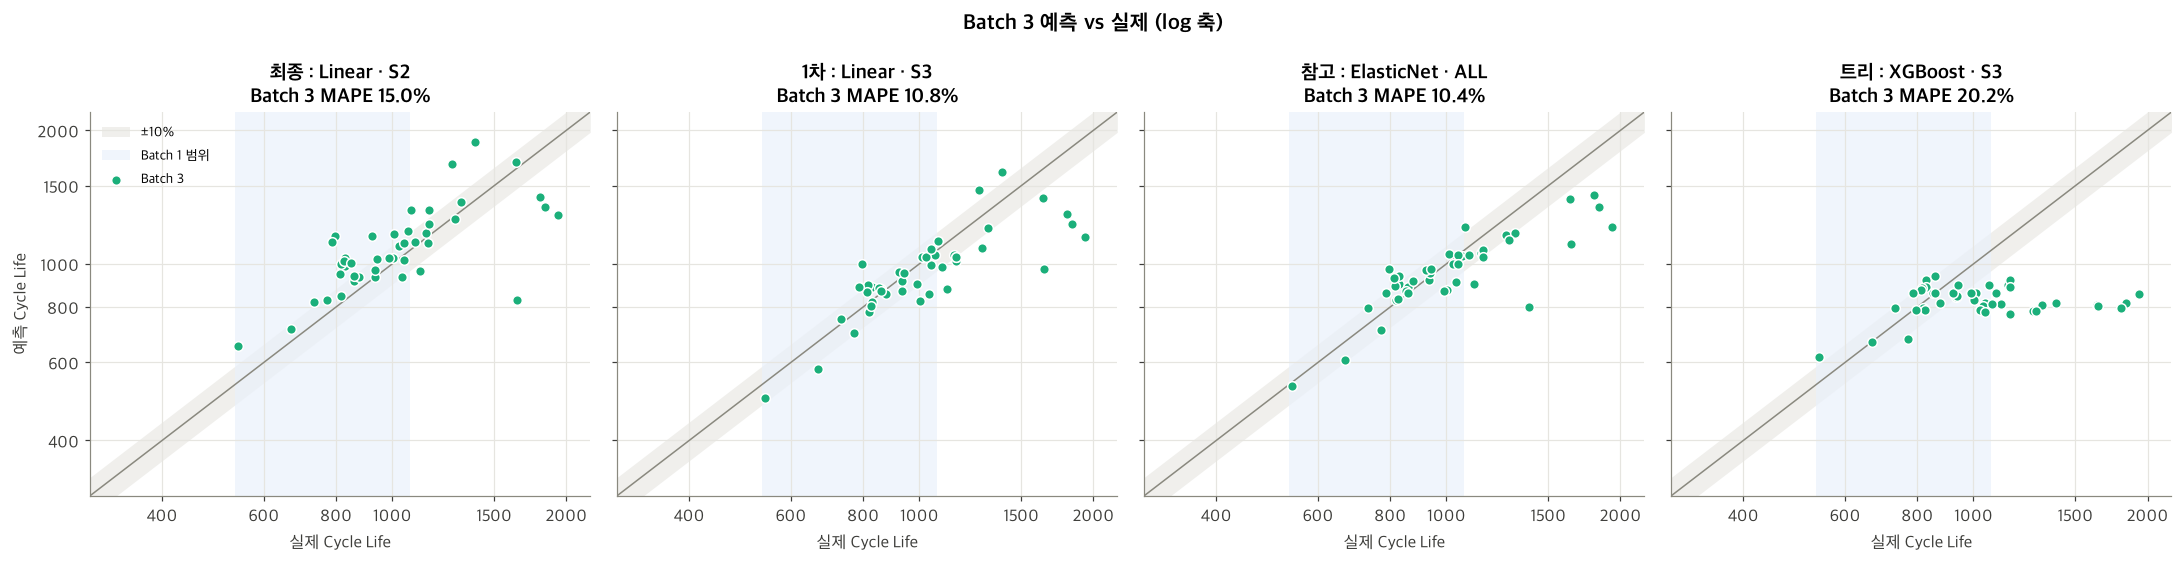

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2), sharex=True, sharey=True)
lims = [300, 2200]
ticks = [400, 600, 800, 1000, 1500, 2000]
for ax, (m, fs, title) in zip(axes, show):
    p = preds_b3[title]
    ax.plot(lims, lims, color=MUTED, lw=1)
    ax.fill_between(lims, [l * 0.9 for l in lims], [l * 1.1 for l in lims], color=GRID, alpha=0.6, lw=0, label="±10%")
    ax.axvspan(b1["cycle_life"].min(), b1["cycle_life"].max(), color="#eaf1fb", alpha=0.7, lw=0, label="Batch 1 범위")
    ax.scatter(b3["cycle_life"], p, s=40, color=BATCH_COLORS["b3"], edgecolor="white", lw=1, label="Batch 3", zorder=3)
    ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims, xlabel="실제 Cycle Life",
           title=f"{title}\nBatch 3 MAPE {mape(b3['cycle_life'], p):.1f}%")
    ax.set_xticks(ticks, [str(t) for t in ticks])
    ax.set_yticks(ticks, [str(t) for t in ticks])
    ax.minorticks_off()
axes[0].set_ylabel("예측 Cycle Life")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Batch 3 예측 vs 실제 (log 축)", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig16_batch3_pred_vs_actual")
plt.show()

---
## 4. 오류 분석

In [7]:
def decompose(y, p):
    logres = np.log10(p) - np.log10(y)
    return pd.Series({"MAPE (%)": mape(y, p), "Spearman": spearmanr(p, y).correlation,
                      "배치 offset (배)": 10 ** logres.mean(),
                      "offset 제거 MAPE (%, 진단)": mape(y, p / 10 ** logres.mean())})


bins = pd.cut(b3["cycle_life"], [0, 800, b1["cycle_life"].max(), 5000],
              labels=["800 미만", f"800 ~ {b1['cycle_life'].max():.0f} (Batch 1 범위 상단)", f"{b1['cycle_life'].max():.0f} 초과 (Batch 1 범위 밖)"])
y = b3["cycle_life"]
signed = pd.DataFrame({t: (p - y) / y * 100 for t, p in preds_b3.items()})

print("수명 구간별 평균 부호 오차 (%) — (+) 면 수명을 길게 예측")
display(pd.concat([signed.groupby(bins).mean().T, bins.value_counts().sort_index().to_frame("셀 수").T]).round(1))

print("오차 구성")
pd.DataFrame({t: decompose(y, p) for t, p in preds_b3.items()}).round(2)

수명 구간별 평균 부호 오차 (%) — (+) 면 수명을 길게 예측


cycle_life,800 미만,800 ~ 1074 (Batch 1 범위 상단),1074 초과 (Batch 1 범위 밖)
최종 : Linear · S2,22.5,10.2,-1.6
1차 : Linear · S3,1.7,-1.2,-13.5
참고 : ElasticNet · ALL,3.6,1.1,-15.7
트리 : XGBoost · S3,3.1,-7.1,-37.4
셀 수,6.0,22.0,16.0


오차 구성


,최종 : Linear · S2,1차 : Linear · S3,참고 : ElasticNet · ALL,트리 : XGBoost · S3
MAPE (%),14.95,10.80,10.37,20.19
Spearman,0.71,0.83,0.80,-0.01
배치 offset (배),1.06,0.94,0.94,0.81
"offset 제거 MAPE (%, 진단)",11.96,11.19,11.00,20.49


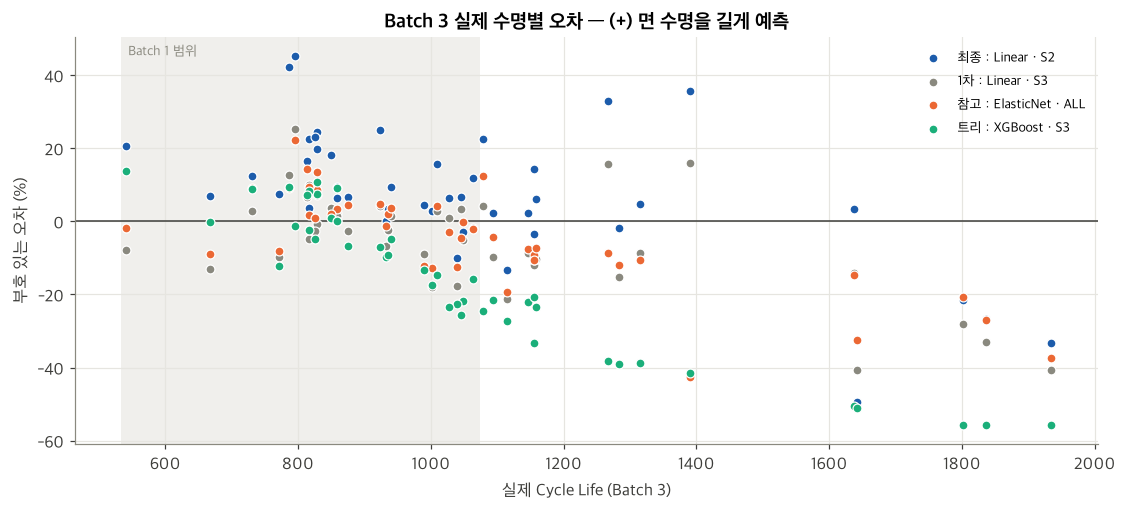

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.8))
for (t, color) in zip(signed.columns, ["#1c5cab", "#8a897f", BATCH_COLORS["b2"], BATCH_COLORS["b3"]]):
    ax.scatter(y, signed[t], s=34, color=color, edgecolor="white", lw=0.8, label=t, zorder=3)
ax.axhline(0, color=TEXT, lw=1)
ax.axvspan(b1["cycle_life"].min(), b1["cycle_life"].max(), color=GRID, alpha=0.6, lw=0)
ax.text(b1["cycle_life"].min() + 10, ax.get_ylim()[1] * 0.9, "Batch 1 범위", color=MUTED, fontsize=9)
ax.set(xlabel="실제 Cycle Life (Batch 3)", ylabel="부호 있는 오차 (%)", title="Batch 3 실제 수명별 오차 — (+) 면 수명을 길게 예측")
ax.legend(fontsize=9)
savefig(fig, "fig17_batch3_error")
plt.show()

In [9]:
final_title = show[0][2]
worst = (b3.assign(예측=preds_b3[final_title].round(0), 오차_pct=signed[final_title].round(1))
           .loc[signed[final_title].abs().sort_values(ascending=False).index[:8], ["policy", "cycle_life", "예측", "오차_pct"]])
print("최종 모델에서 오차가 가장 큰 Batch 3 셀 8개")
worst

최종 모델에서 오차가 가장 큰 Batch 3 셀 8개


,policy,cycle_life,예측,오차_pct
cell_id,,,,
b3c42,4.8C(80%)-4.8C-newstructure,1642.0,831.0,-49.4
b3c40,5.6C(19%)-4.6C-newstructure,796.0,1157.0,45.3
b3c41,5.6C(36%)-4.3C-newstructure,786.0,1118.0,42.2
b3c37,4.8C(80%)-4.8C-newstructure,1390.0,1884.0,35.5
b3c38,5C(67%)-4C-newstructure,1935.0,1291.0,-33.3
b3c2,5.6C(19%)-4.6C-newstructure,1267.0,1684.0,32.9
b3c7,4.8C(80%)-4.8C-newstructure,1836.0,1344.0,-26.8
b3c36,5.6C(36%)-4.3C-newstructure,923.0,1153.0,24.9


### Batch 2 와 Batch 3 의 offset 비교

`02_modeling` 에서는 Batch 2 의 offset 원인으로 휴지 시간 차이를 추정했다. Batch 3 는 Batch 2 의 newstructure 셀과 휴지 시간이 같으므로(약 0.3분), 두 그룹의 오차를 비교하면 이 가설을 확인할 수 있다.

In [10]:
b2_pred = final_r["test_pred"]
rows = {
    "Batch 2 일반 셀 (휴지 약 21분)": (b2.loc[~b2["newstructure"], "cycle_life"], b2_pred[~b2["newstructure"]]),
    "Batch 2 newstructure 셀 (휴지 약 0.3분)": (b2.loc[b2["newstructure"], "cycle_life"], b2_pred[b2["newstructure"]]),
    "Batch 3 newstructure 셀 (휴지 약 0.3분)": (y, preds_b3[final_title]),
}
pd.DataFrame({k: {"셀 수": len(a), "평균 부호 오차 (%)": ((p - a) / a * 100).mean(), "MAPE (%)": mape(a, p)}
              for k, (a, p) in rows.items()}).T.round(1)

,셀 수,평균 부호 오차 (%),MAPE (%)
Batch 2 일반 셀 (휴지 약 21분),30.0,30.2,30.2
Batch 2 newstructure 셀 (휴지 약 0.3분),9.0,28.3,28.3
Batch 3 newstructure 셀 (휴지 약 0.3분),44.0,7.6,15.0


**[오류 분석 해석]**
- **offset 이 거의 없다** : 최종 모델은 Batch 3 에서 예측이 실제보다 평균 1.06배로, Batch 2 (1.29배)와 달리 배치 전체가 밀리지 않았다. 남은 오차는 셀 개별 오차다 (offset 을 빼도 12.0%)
- **긴 수명 쪽 외삽** : Batch 1 최대 수명(1074)보다 긴 16개 셀을 최종 모델은 −1.6% 로 맞혔다. 반면 1차 · ElasticNet · XGBoost 는 −13.5 ~ −37.4% 로 짧게 예측했다. 특히 XGBoost 는 Batch 1 최대 수명 근처에서 예측이 막혀 순서 상관이 −0.01 로 무너졌다 → 트리 모델은 짧은 쪽(Batch 2) 과 긴 쪽(Batch 3) 모두 학습 범위 밖을 예측하지 못한다
- **짧은 셀은 길게 예측** : 800 미만 6개 셀은 +22.5% 로 길게 예측했다
- **같은 정책 안에서도 양쪽으로 크게 틀린 셀이 있다** : `4.8C(80%)-4.8C` 정책의 `b3c42` 는 1642 → 831 (−49%), `b3c37` 은 1390 → 1884 (+36%). EDA Q4 에서 Batch 3 는 같은 정책 안에서도 수명 편차가 크다고 확인했다 → 초기 100 사이클의 ΔQ 만으로는 설명되지 않는 셀 개별 차이가 있는 것 같다. 측정 오류라는 근거는 없어 제거하지 않았다
- **휴지 시간 가설 수정** : Batch 2 의 newstructure 셀은 휴지 시간이 Batch 3 와 같은데도(약 0.3분) +28.3% 로, 휴지 시간이 약 21분인 Batch 2 일반 셀(+30.2%)과 비슷하게 밀렸다. 반면 Batch 3 는 +7.6% 다 → Batch 2 의 offset 은 휴지 시간보다 **Batch 2 배치 전체에 공통된 요인**(셀 생산 로트, 시험 시기 등)에서 온 것 같다. 이 정보는 데이터에 없어 직접 확인하지는 못했다

**[Gap 해석]**
- Gap (Batch2-Batch3) = −14.8%p (계산 : Batch 3 − Batch 2) : Batch 3 가 더 좋다. Batch 3 는 offset 이 1.06배로 Batch 2 (1.29배)보다 훨씬 작기 때문이다. 피처가 Batch 2 에 과적합됐다면 Batch 3 에서 더 나빠졌을 텐데 그렇지 않다
- 모델별로 보면 `qd_2` 가 들어간 1차 모델(S3)이 43.5% → 10.8% 로 가장 크게 흔들렸다. `qd_2` 가 Batch 2 에서는 높은 쪽(+1.88), Batch 3 에서는 낮은 쪽(−1.72)으로 이동하면서 오차를 키웠다가 줄였다 → **`qd_2` 는 배치에 따라 결과가 크게 달라지는 피처**라는 02 의 판단을 다시 확인했다
- Gap (Target-Test) · Batch 3 = +5.9%p : Batch 2 (+20.7%p) 보다 원논문 Target 에 훨씬 가깝다. 남은 5.9%p 는 offset 이 아니라 **셀 개별 오차**에서 온다 (offset 1.06배, offset 을 빼도 12.0%) → 800 미만 짧은 셀을 +22.5% 길게 예측했고, 같은 정책 안에서도 수명이 크게 다른 셀(`b3c42` 1642 vs `b3c37` 1390)을 양쪽으로 틀렸다
- 참고로 ElasticNet · ALL 은 Batch 2 · 3 모두에서 최종 모델보다 낮았다 (27.3% / 10.4%). 테스트셋을 보고 알게 된 결과라 최종 모델은 바꾸지 않았지만, 규제로 여러 피처를 약하게 섞는 방식이 배치 간 흔들림을 줄였을 가능성이 있어 새로운 배치로 추가 검증해볼 만하다

---
## 5. 결론
- 최종 모델(Linear · `dq_var`, `dq_lowv_mean`)을 그대로 적용한 Batch 3 MAPE 는 **15.0%** (Batch 2 29.8%, Target 9.1%)
- 같은 모델이라도 배치에 따라 offset 이 1.29배(Batch 2) ~ 1.06배(Batch 3) 로 크게 달라진다 → 배치마다 기준 셀로 보정하는 과정이 필요하다는 결론을 Batch 3 에서도 확인했다
- Batch 2 의 offset 은 휴지 시간이 아니라 Batch 2 배치 자체의 요인으로 보인다 (02 의 가설을 수정)
- 선형 모델은 짧은 쪽 · 긴 쪽 모두 학습 범위 밖을 예측할 수 있었고, 트리 모델은 양쪽 모두 실패했다 → EDA 에서 선형 계열을 주력으로 정한 판단이 맞았다